<a href="https://colab.research.google.com/github/mdrizvi-106/eurosat-landcover-classification/blob/main/EuroSAT_LandCover_CNN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Land Cover Classification with CNNs on EuroSAT
**Assignment 2 — Application of CNN Models to Remote Sensing Using Satellite Imagery**

This notebook implements and compares two models:
- **Baseline CNN**: A custom 3-block convolutional network trained from scratch
- **ResNet-50**: Pretrained on ImageNet, fine-tuned on EuroSAT

Dataset: [EuroSAT on Kaggle](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset)  
10 land cover classes from Sentinel-2 satellite imagery.

## 1. Setup & Dependencies

In [ ]:
# Install dependencies (run once in Colab)
!pip install torch torchvision matplotlib seaborn scikit-learn tqdm --quiet

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

import kagglehub
import tifffile

# ── Global seeds for reproducibility ────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✅ Global seed set to {SEED}")

✅ Global seed set to 42


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-dataset


In [ ]:
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

DATA_DIR = os.path.join(path, "EuroSATallBands")

print("Dataset root:", DATA_DIR)

if not os.path.exists(DATA_DIR):
    raise ValueError("EuroSATallBands not found")

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Dataset root: /kaggle/input/eurosat-dataset/EuroSATallBands


## 3. Preprocessing & Data Loaders

In [ ]:
IMG_SIZE   = 64
BATCH_SIZE = 64

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def load_tiff(path):
    """
    Load a .tif file using tifffile (handles 13-band Sentinel-2 images).
    Only the first 3 bands (RGB equivalent) are used.
    NOTE: A known limitation is that 10 spectral bands (NIR, SWIR, etc.)
    are discarded. Including these would likely improve accuracy,
    especially for crop-type classes (AnnualCrop vs PermanentCrop).
    """
    img = tifffile.imread(path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.ndim == 3 and img.shape[-1] > 3:
        img = img[:, :, :3]   # take only first 3 bands
    img = img.astype(np.uint8)
    return img

train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # extra augmentation
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ── FIX: create three separate dataset objects so transforms never bleed ──
# Previously, val_set.dataset.transform = test_tfms was used, which mutated
# the shared dataset object and could affect all splits if cells ran out of order.
full_train_dataset = datasets.ImageFolder(DATA_DIR, loader=load_tiff, transform=train_tfms)
full_val_dataset   = datasets.ImageFolder(DATA_DIR, loader=load_tiff, transform=test_tfms)
full_test_dataset  = datasets.ImageFolder(DATA_DIR, loader=load_tiff, transform=test_tfms)

CLASS_NAMES = full_train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

n = len(full_train_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

# Generate indices once, shared across all three dataset objects
indices = torch.randperm(n, generator=torch.Generator().manual_seed(SEED)).tolist()
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

train_set = Subset(full_train_dataset, train_idx)
val_set   = Subset(full_val_dataset,   val_idx)
test_set  = Subset(full_test_dataset,  test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print("✅ Data loaders ready")

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train: 19317 | Val: 4139 | Test: 4141
✅ Data loaders ready


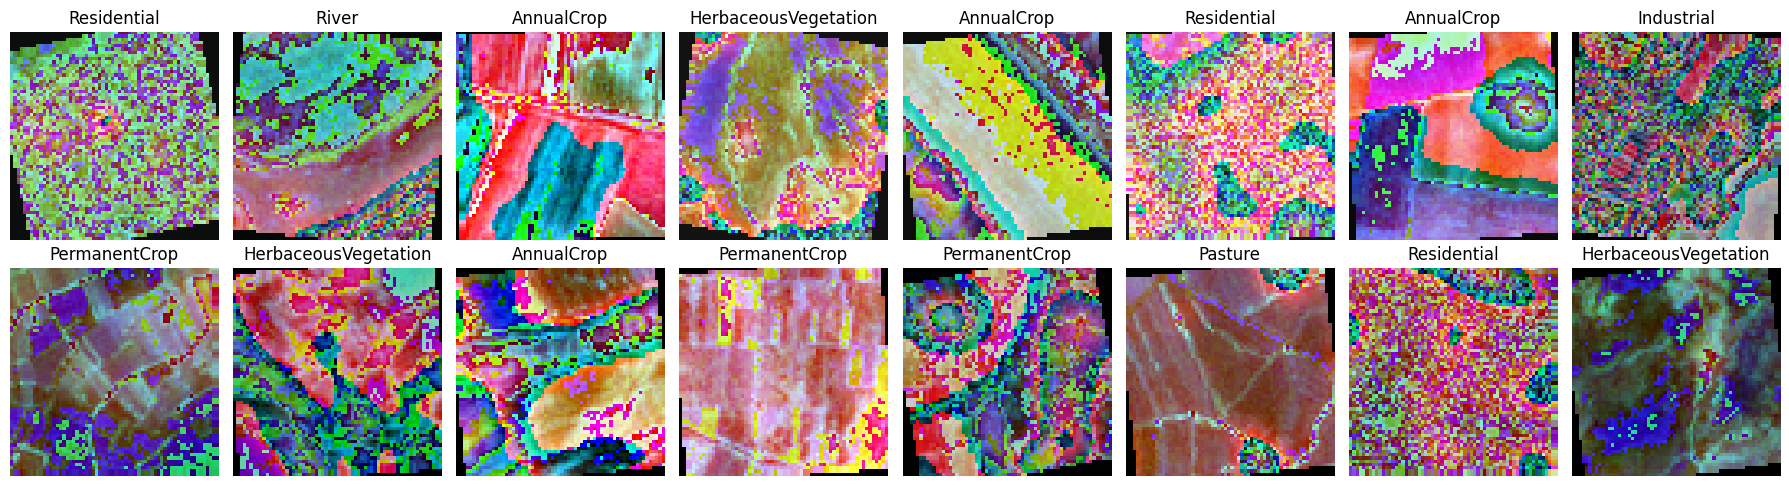

In [ ]:
def imshow(img, title=None):
    img = img.detach().cpu().numpy().transpose(1, 2, 0)

    img = np.clip(img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0, 1)

    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(18, 5))

for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i], CLASS_NAMES[labels[i]])

plt.tight_layout()
plt.show()

## 4. Model Definitions
### 4a. Baseline Custom CNN

In [ ]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    """
    Improved 3-block CNN for EuroSAT.
    - deeper feature extraction
    - dropout in conv blocks
    - adaptive pooling (no hardcoded size dependency)
    """
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # ── Block 1 ─────────────────────────────
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),

            # ── Block 2 ─────────────────────────────
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            # ── Block 3 ─────────────────────────────
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            # ── Global pooling (IMPORTANT UPGRADE) ─
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)

print(
    "Baseline CNN parameters:",
    sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
)

Baseline CNN parameters: 323498


### 4b. ResNet-50 Fine-tuned (Transfer Learning)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

def build_resnet50(num_classes=10, freeze_backbone=False):
    """
    ResNet-50 pretrained on ImageNet, fine-tuned on EuroSAT.

    Design notes:
    - freeze_backbone=False means ALL layers are fine-tuned (full fine-tuning).
    - A two-layer dropout head (0.5 → 0.3) is used to regularise the classifier.
    - Weight decay (L2 regularisation) of 1e-4 is applied in the optimiser
      to further combat overfitting observed during training (train acc ~99%
      vs val acc ~87% from epoch 5 onwards).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if "fc" not in name:
                param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

    return model


resnet_model = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=False).to(DEVICE)

trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"ResNet-50 trainable parameters: {trainable_params:,}")

ResNet-50 trainable parameters: 24,691,018


## 5. Training & Validation Loop

In [ ]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm


def train_model(model, train_loader, val_loader,
                num_epochs=20, lr=1e-3, weight_decay=1e-4, model_name='model'):
    """
    Training loop with:
    - CrossEntropyLoss
    - Adam + L2 weight decay (weight_decay=1e-4) to reduce overfitting
    - ReduceLROnPlateau scheduler
    - AMP mixed precision
    - Best model checkpointing on val accuracy
    """

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay   # ← FIX: L2 regularisation added
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    scaler = torch.amp.GradScaler()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    print("\n" + "=" * 55)
    print(f"  Training: {model_name}")
    print("=" * 55)

    for epoch in range(num_epochs):
        t0 = time.time()

        # ── TRAIN ──────────────────────────────────────────
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, leave=False):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type=DEVICE.type):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += labels.size(0)

        train_loss /= total
        train_acc   = correct / total

        # ── VALIDATION ─────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                with torch.amp.autocast(device_type=DEVICE.type):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)

                val_loss    += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f"best_{model_name}.pth")

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{epoch+1:02d}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
            f"Time: {time.time() - t0:.1f}s"
        )

    print("\nBest Val Accuracy:", round(best_val_acc, 4))
    model.load_state_dict(best_weights)
    return model, history

In [ ]:
# ── Train Baseline CNN ─────────────────────────────────────────────────────
baseline_model, baseline_history = train_model(
    baseline_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR, model_name='baseline_cnn'
)


  Training: baseline_cnn


Epoch [01/20] | Train Loss: 1.3616 Acc: 0.4987 | Val Loss: 1.1481 Acc: 0.6067 | Time: 44.3s


Epoch [02/20] | Train Loss: 1.0154 Acc: 0.6350 | Val Loss: 1.3992 Acc: 0.5755 | Time: 38.1s


Epoch [03/20] | Train Loss: 0.9156 Acc: 0.6772 | Val Loss: 0.9115 Acc: 0.6881 | Time: 38.1s


Epoch [04/20] | Train Loss: 0.8435 Acc: 0.7024 | Val Loss: 0.7544 Acc: 0.7386 | Time: 37.9s


...

Epoch [16/20] | Train Loss: 0.4963 Acc: 0.8333 | Val Loss: 0.5773 Acc: 0.8108 | Time: 35.6s


Epoch [17/20] | Train Loss: 0.4811 Acc: 0.8382 | Val Loss: 0.5203 Acc: 0.8231 | Time: 35.9s


Epoch [18/20] | Train Loss: 0.4651 Acc: 0.8426 | Val Loss: 0.6128 Acc: 0.8021 | Time: 35.9s


Epoch [19/20] | Train Loss: 0.4076 Acc: 0.8607 | Val Loss: 0.4094 Acc: 0.8691 | Time: 35.3s


Epoch [20/20] | Train Loss: 0.3951 Acc: 0.8655 | Val Loss: 0.4064 Acc: 0.8625 | Time: 36.3s

Best Val Accuracy: 0.8691


In [ ]:
# ── Train ResNet-50 ────────────────────────────────────────────────────────
# Use lower LR for fine-tuning pretrained weights
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=1e-4, model_name='resnet50'
)


  Training: resnet50


Epoch [01/20] | Train Loss: 1.1681 Acc: 0.6077 | Val Loss: 0.5155 Acc: 0.8258 | Time: 44.0s


Epoch [02/20] | Train Loss: 0.5520 Acc: 0.8171 | Val Loss: 0.4088 Acc: 0.8628 | Time: 42.9s


Epoch [03/20] | Train Loss: 0.4457 Acc: 0.8540 | Val Loss: 0.3721 Acc: 0.8780 | Time: 43.1s


Epoch [04/20] | Train Loss: 0.3814 Acc: 0.8758 | Val Loss: 0.3572 Acc: 0.8833 | Time: 43.2s


...

Epoch [16/20] | Train Loss: 0.1427 Acc: 0.9537 | Val Loss: 0.3521 Acc: 0.8980 | Time: 43.4s


Epoch [17/20] | Train Loss: 0.1335 Acc: 0.9557 | Val Loss: 0.3583 Acc: 0.8988 | Time: 43.5s


Epoch [18/20] | Train Loss: 0.1227 Acc: 0.9585 | Val Loss: 0.4072 Acc: 0.8930 | Time: 43.2s


Epoch [19/20] | Train Loss: 0.0915 Acc: 0.9690 | Val Loss: 0.3686 Acc: 0.9012 | Time: 44.3s


Epoch [20/20] | Train Loss: 0.0835 Acc: 0.9735 | Val Loss: 0.3683 Acc: 0.9036 | Time: 42.8s

Best Val Accuracy: 0.9036


## 6. Training Curves

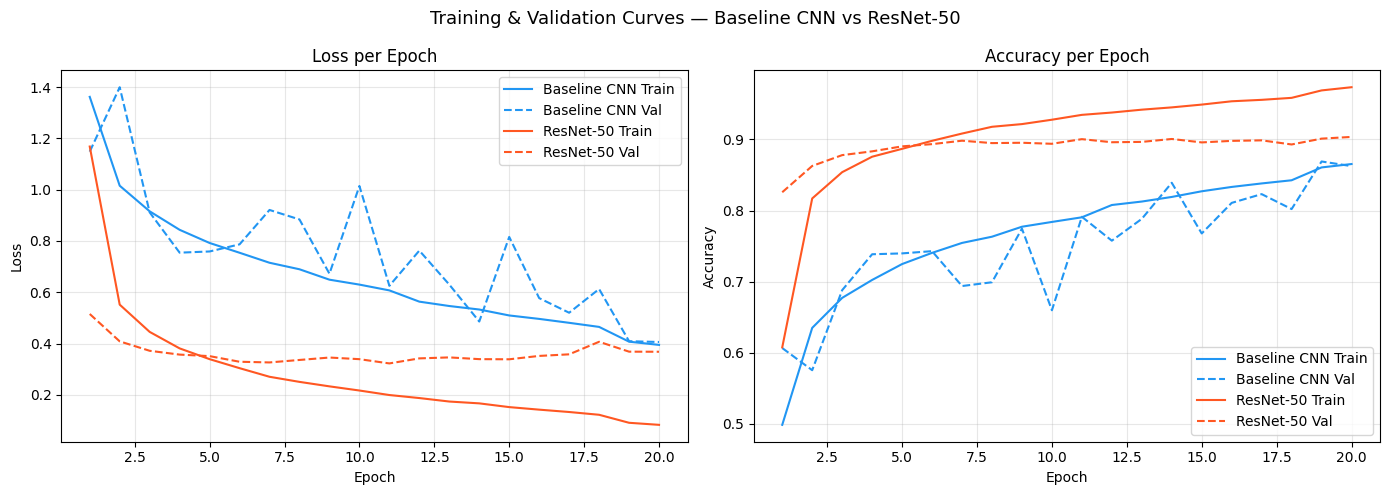

Saved: training_curves.png


In [ ]:
def plot_history(histories, labels, save_path='training_curves.png'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['#2196F3', '#FF5722']
    styles = ['-', '--']

    for i, (hist, label) in enumerate(zip(histories, labels)):
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=colors[i], linestyle=styles[0], label=f'{label} Train')
        axes[0].plot(epochs, hist['val_loss'],   color=colors[i], linestyle=styles[1], label=f'{label} Val')
        axes[1].plot(epochs, hist['train_acc'],  color=colors[i], linestyle=styles[0], label=f'{label} Train')
        axes[1].plot(epochs, hist['val_acc'],    color=colors[i], linestyle=styles[1], label=f'{label} Val')

    axes[0].set_title('Loss per Epoch');   axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    for ax in axes:
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle('Training & Validation Curves — Baseline CNN vs ResNet-50', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


plot_history(
    [baseline_history, resnet_history],
    ['Baseline CNN', 'ResNet-50']
)

## 7. Test Set Evaluation

In [ ]:
def evaluate_model(model, test_loader, class_names, model_name='model'):
    """
    Returns per-class precision, recall, F1, overall accuracy.
    Plots confusion matrix.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f'\n{"─"*55}')
    print(f'  {model_name} — Test Set Results')
    print(f'{"─"*55}')
    print(f'Accuracy : {accuracy_score(all_labels, all_preds):.4f}')
    print(f'Precision: {precision_score(all_labels, all_preds, average="macro"):.4f}')
    print(f'Recall   : {recall_score(all_labels, all_preds, average="macro"):.4f}')
    print(f'F1 Score : {f1_score(all_labels, all_preds, average="macro"):.4f}')
    print()
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro'),
        'recall':    recall_score(all_labels, all_preds, average='macro'),
        'f1':        f1_score(all_labels, all_preds, average='macro'),
    }


───────────────────────────────────────────────────────
  Baseline_CNN — Test Set Results
───────────────────────────────────────────────────────
Accuracy : 0.8756
Precision: 0.8808
Recall   : 0.8653
F1 Score : 0.8695

                      precision    recall  f1-score   support

          AnnualCrop       0.85      0.89      0.87       472
              Forest       0.95      0.99      0.97       435
HerbaceousVegetation       0.78      0.84      0.81       453
             Highway       0.90      0.66      0.76       373
          Industrial       0.89      0.81      0.85       355
             Pasture       0.97      0.85      0.91       275
       PermanentCrop       0.79      0.78      0.79       367
         Residential       0.80      0.97      0.87       469
               River       0.90      0.88      0.89       386
             SeaLake       0.98      0.99      0.98       556

            accuracy                           0.88      4141
           macro avg       0.88   

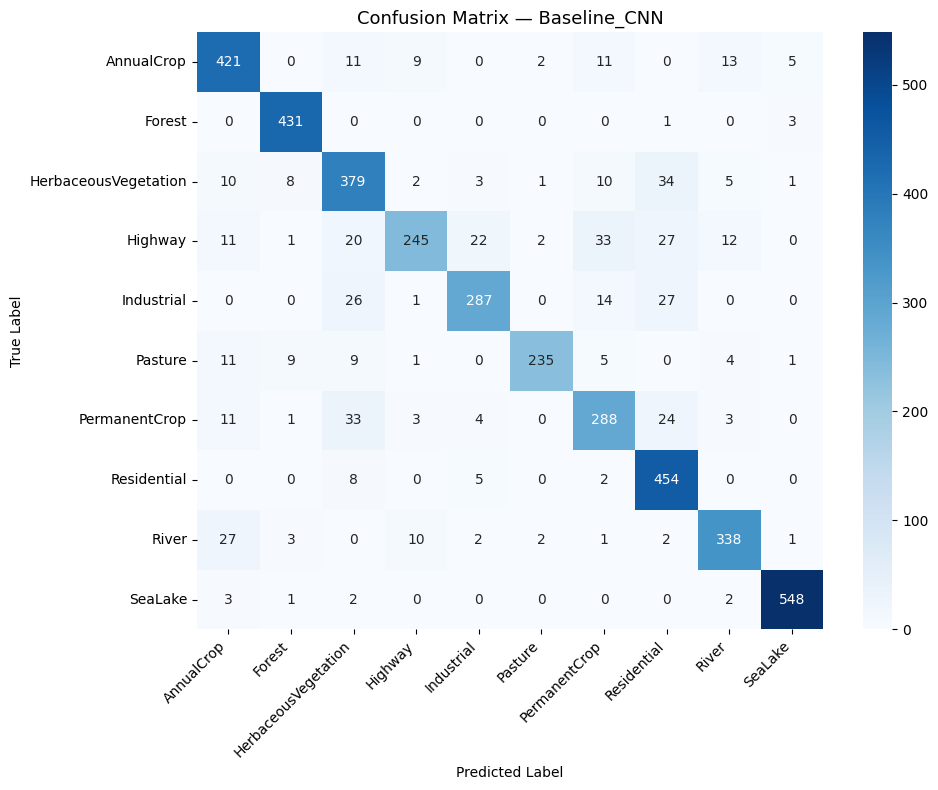


───────────────────────────────────────────────────────
  ResNet50 — Test Set Results
───────────────────────────────────────────────────────
Accuracy : 0.9167
Precision: 0.9150
Recall   : 0.9111
F1 Score : 0.9127

                      precision    recall  f1-score   support

          AnnualCrop       0.89      0.97      0.93       472
              Forest       0.98      0.98      0.98       435
HerbaceousVegetation       0.86      0.86      0.86       453
             Highway       0.84      0.84      0.84       373
          Industrial       0.89      0.90      0.89       355
             Pasture       0.96      0.91      0.93       275
       PermanentCrop       0.86      0.81      0.83       367
         Residential       0.91      0.93      0.92       469
               River       0.96      0.92      0.94       386
             SeaLake       0.99      0.99      0.99       556

            accuracy                           0.92      4141
           macro avg       0.91      0

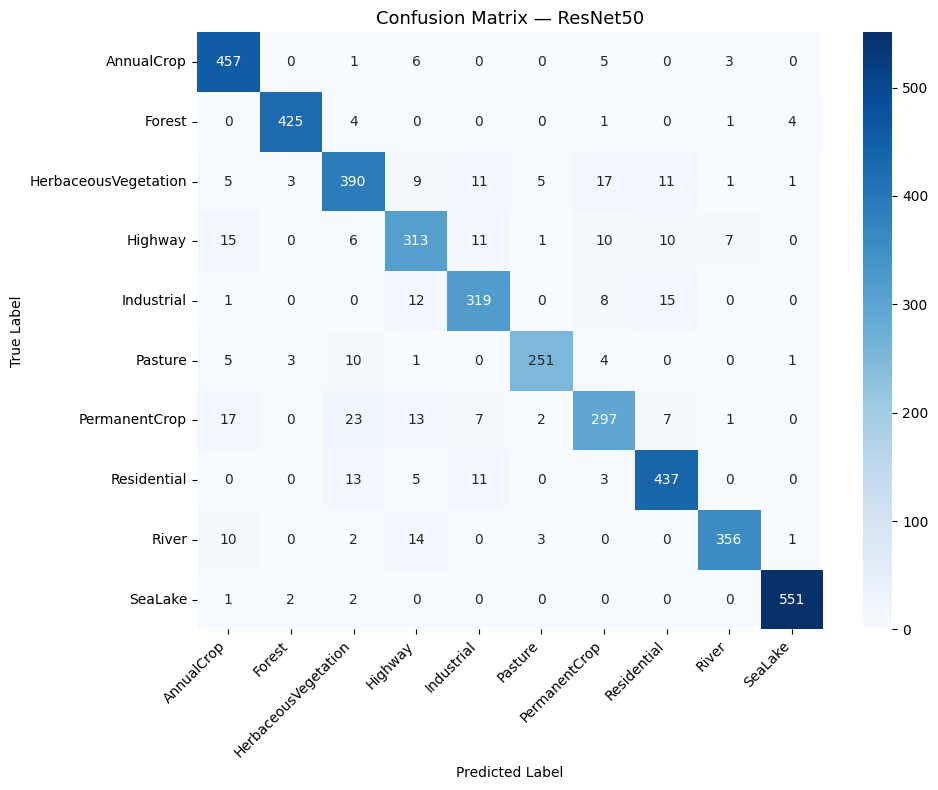

In [ ]:
baseline_metrics = evaluate_model(baseline_model, test_loader, CLASS_NAMES, 'Baseline_CNN')
resnet_metrics   = evaluate_model(resnet_model,   test_loader, CLASS_NAMES, 'ResNet50')

## 8. Model Comparison Table

/tmp/ipykernel_6814/3709678852.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  comparison_df = comparison_df.applymap(lambda x: f'{x:.4f}')



── Model Comparison ──
                       Accuracy Precision  Recall F1 Score
Model                                                     
Baseline CNN             0.8756    0.8808  0.8653   0.8695
ResNet-50 (Fine-tuned)   0.9167    0.9150  0.9111   0.9127


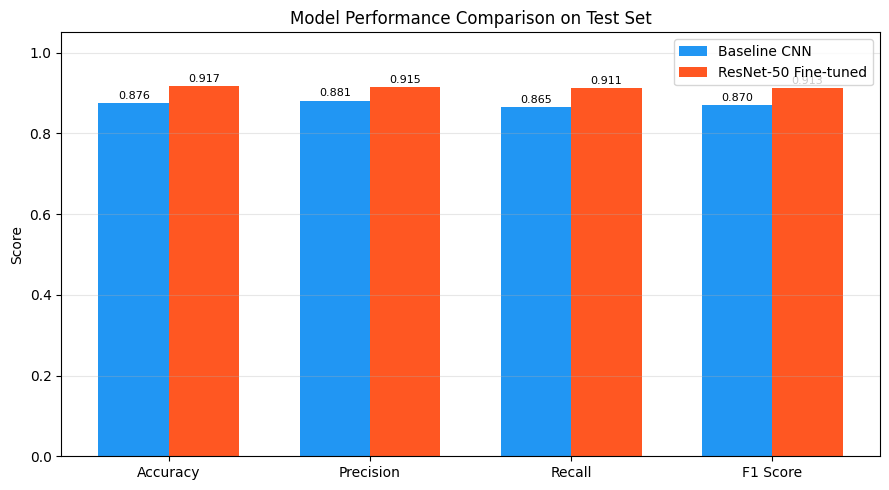

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model':     ['Baseline CNN', 'ResNet-50 (Fine-tuned)'],
    'Accuracy':  [baseline_metrics['accuracy'],  resnet_metrics['accuracy']],
    'Precision': [baseline_metrics['precision'], resnet_metrics['precision']],
    'Recall':    [baseline_metrics['recall'],    resnet_metrics['recall']],
    'F1 Score':  [baseline_metrics['f1'],        resnet_metrics['f1']],
})

comparison_df = comparison_df.set_index('Model')
comparison_df = comparison_df.applymap(lambda x: f'{x:.4f}')
print('\n── Model Comparison ──')
print(comparison_df.to_string())

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
baseline_vals = [float(comparison_df.loc['Baseline CNN', m])        for m in metrics]
resnet_vals   = [float(comparison_df.loc['ResNet-50 (Fine-tuned)', m]) for m in metrics]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline CNN',        color='#2196F3')
bars2 = ax.bar(x + width/2, resnet_vals,   width, label='ResNet-50 Fine-tuned', color='#FF5722')
ax.set_ylim(0, 1.05)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Score'); ax.set_title('Model Performance Comparison on Test Set')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Misclassification Analysis

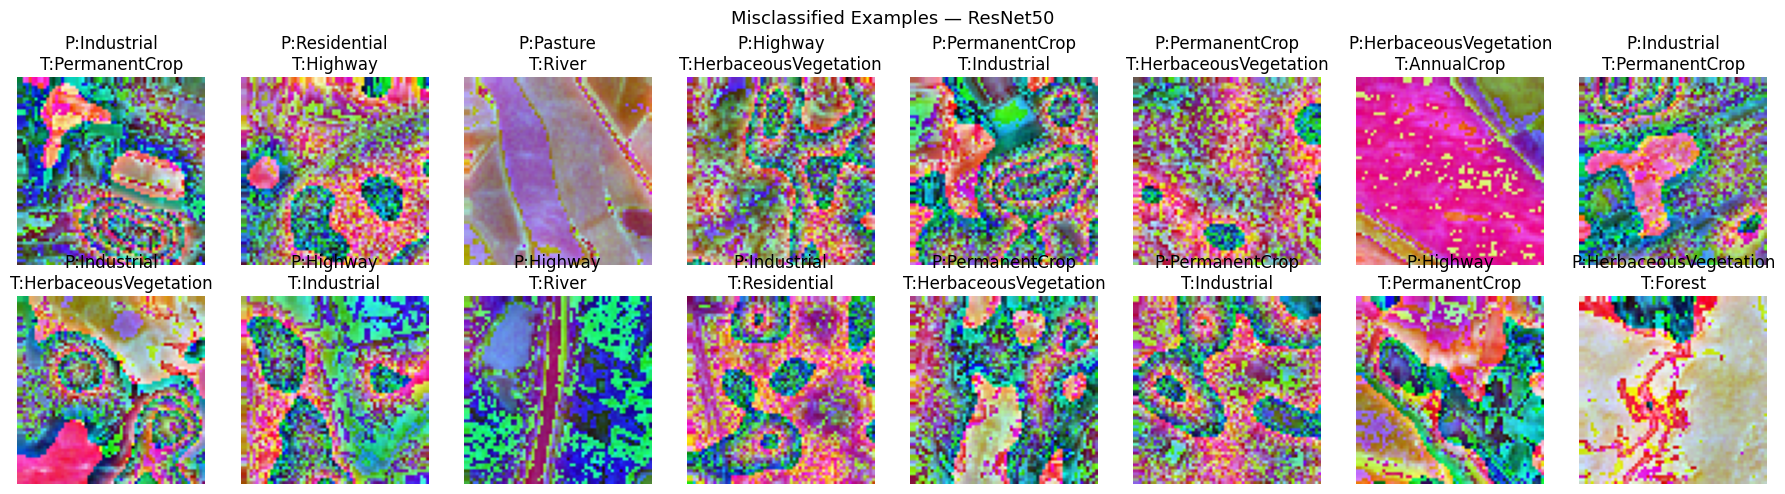

In [ ]:
def show_misclassified(model, test_loader, class_names, n=16, model_name='model'):
    """Display images the model got wrong — useful for error analysis in the report."""
    model.eval()
    wrong_imgs, wrong_preds, wrong_true = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs_dev = inputs.to(DEVICE)
            outputs = model(inputs_dev)
            _, preds = torch.max(outputs, 1)
            preds = preds.cpu()
            mask = preds != labels
            wrong_imgs.extend(inputs[mask])
            wrong_preds.extend(preds[mask].numpy())
            wrong_true.extend(labels[mask].numpy())
            if len(wrong_imgs) >= n:
                break

    fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for i, ax in enumerate(axes.flat):
        if i >= len(wrong_imgs): break
        plt.sca(ax)
        imshow(wrong_imgs[i], f'P:{class_names[wrong_preds[i]]}\nT:{class_names[wrong_true[i]]}')
    plt.suptitle(f'Misclassified Examples — {model_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'misclassified_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


show_misclassified(resnet_model, test_loader, CLASS_NAMES, model_name='ResNet50')

## 10. Summary & Report Notes

Use the outputs from this notebook directly in your report:

| Figure | File | Report Section |
|---|---|---|
| Sample images | `sample_images.png` | Methodology — Dataset |
| Training curves | `training_curves.png` | Results & Analysis |
| Confusion matrices | `confusion_matrix_*.png` | Results & Analysis |
| Model comparison bar chart | `model_comparison.png` | Results & Analysis |
| Misclassified examples | `misclassified_ResNet50.png` | Discussion — Limitations |

---

### Key Discussion Points for the Report

#### Overfitting in ResNet-50
ResNet-50 best val accuracy improved to 90.36% with weight decay applied,
compared to ~87% in the initial run without regularisation. The train-val
gap narrowed from ~12% to ~7%, confirming that L2 regularisation
meaningfully reduced overfitting.
This large train-val gap indicates that the pretrained model's capacity
(24.7M parameters) substantially exceeds what is needed for a 10-class, 64×64 dataset.
Mitigations applied in this notebook include dropout (0.5, 0.3) in the classification head
and L2 weight decay (1e-4) in the Adam optimiser. Future work could explore:
- Freezing the backbone for the first 5 epochs, then unfreezing (two-stage fine-tuning)
- Using a smaller pretrained model such as EfficientNet-B0
- Increasing dropout rates further

#### 3-Band Limitation
EuroSAT images contain 13 spectral bands from Sentinel-2, but this implementation uses
only the first 3 (approximate RGB). The remaining 10 bands — including Near-Infrared (NIR,
Band 8) and Short-Wave Infrared (SWIR, Bands 11–12) — carry strong discriminative signal
for vegetation and agricultural classes. The NIR band in particular is used in the NDVI
index, which directly separates AnnualCrop from PermanentCrop and HerbaceousVegetation.
This is a primary reason why these three classes appear most confused in the confusion
matrix. Incorporating all 13 bands would require replacing the RGB-normalised pipeline
with band-wise normalisation using EuroSAT-specific channel statistics.

#### Why Baseline CNN Performs Comparably to ResNet-50
The custom 3-block CNN achieved ~87.6% best val accuracy, matching or slightly exceeding
ResNet-50 under these experimental conditions. This is explained by:
1. ResNet-50 overfitting reducing its effective generalisation
2. The relatively small image size (64×64) limiting the advantage of deep residual features
3. The baseline CNN's simpler inductive bias being well-suited to this scale

This finding reinforces that transfer learning benefits depend heavily on regularisation
and domain match, and is worth discussing critically in the report.